In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow import keras

In [3]:
MAIN_DIR = "D:\IMAGE2MASS"
IMAGE_DIR = MAIN_DIR + '\\' + 'imagery' + '\\' + 'realsense_overhead'
DISH_DATA_CAFE_1_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe1.csv"
DISH_DATA_CAFE_2_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe2.csv"

In [4]:
cafe1 = pd.read_csv(DISH_DATA_CAFE_1_FILE, header=None, on_bad_lines='skip')
cafe2 = pd.read_csv(DISH_DATA_CAFE_2_FILE, header=None, on_bad_lines='skip')

In [5]:
cafe1.head()

,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,ingr_0000000508,soy sauce,3.398568,1.801241,...,0.000425,0.019754,0.004248,ingr_0000000513,millet,3.414345,4.063071,0.034143,0.80920,0.119502
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,ingr_0000000433,roasted potatoes,17.000000,23.970000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,ingr_0000000312,pepper,0.300716,0.120286,...,0.000000,0.000000,0.000000,ingr_0000000524,parsley,0.752816,0.279295,0.006023,0.04818,0.021832
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,ingr_0000000448,jalapenos,0.192961,0.055959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,ingr_0000000471,cherry tomatoes,55.000000,9.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# more efficient than .drop()
cafe1 = cafe1.iloc[:, :6]
cafe2 = cafe2.iloc[:, :6]

In [ ]:
column_names = {0: "dish_id", 1: "total_weight", 2: "total_calories", 3: "total_fat", 4: "total_carb", 5: "total_protein"}
cafe1 = cafe1.rename(columns=column_names)
cafe2 = cafe2.rename(columns=column_names)

In [21]:
df = pd.concat([cafe1, cafe2], ignore_index=True)
df.head()

,dish_id,total_weight,total_calories,total_fat,total_carb,total_protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
2,dish_1566417516,385.402527,425.0,36.516472,23.505039,33.699574
3,dish_1563998210,148.089218,91.0,4.958992,2.163187,22.614895
4,dish_1561061658,226.000137,227.0,12.284481,24.678637,8.949248


In [ ]:
import os
df["image_path"] = df["dish_id"].apply(lambda x: os.path.join(IMAGE_DIR, x)) # need only this column
df["image_rgb_path"] = df["image_path"].apply(lambda x: os.path.join(x, "rgb.png"))
df["image_depth_raw_path"] = df["image_path"].apply(lambda x: os.path.join(x, "depth_raw.png"))
df["image_depth_color_path"] = df["image_path"].apply(lambda x: os.path.join(x, "depth_color.png"))

In [46]:
df.head()

,dish_id,total_weight,total_calories,total_fat,total_carb,total_protein,image_path,image_rgb_path,image_depth_raw_path,image_depth_color_path
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
2,dish_1566417516,385.402527,425.0,36.516472,23.505039,33.699574,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
3,dish_1563998210,148.089218,91.0,4.958992,2.163187,22.614895,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
4,dish_1561061658,226.000137,227.0,12.284481,24.678637,8.949248,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...


In [47]:
from PIL import Image
def visualize_image(image_path: str) -> None:
    img_matrix = np.asarray(Image.open(image_path))
    print(f"Image shape: {img_matrix.shape}")
    plt.imshow(img_matrix)

Image shape: (480, 640, 3)


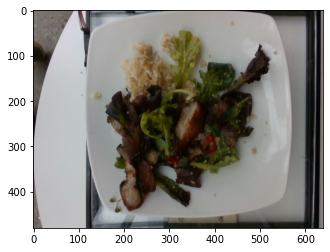

In [48]:
visualize_image(df["image_rgb_path"][0])